In [1]:
import os
import sys

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import sim_data_analysis as sda

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

In [2]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=3, count=4, shape="square"
)

fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(
    irradiance=2.5,
    wavelength=640,
    bleaching=True,
    energy_transfer=True,
    dstorm=True,
    reducing_agent="mea",
    concentration=100,
    ph=7.5,
)

transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.adjust_rates({5:2e4, 4:1e7, 14:1e3, 13:4e4})
transition_set = transition_set.adjust_rates({16:6.3e9, 17:2e8, 21:2e9, 22:8e8, 23:2e7, 27:2.4e8})
transition_set = transition_set.filter_by_identity([19, 25])
transition_set.finalize()

In [3]:
transition_set.transition_df

transition_type  \
Fluorophore                         identity                                           
cy5_dna                             0                      TransitionType.EXCITATION   
                                    1            TransitionType.FLUORESCENT_EMISSION   
                                    2         TransitionType.INTERSYSTEM_CROSSING_ST   
                                    3         TransitionType.INTERSYSTEM_CROSSING_TS   
                                    4                   TransitionType.ISOMERIZATION   
                                    5                      TransitionType.PHOTO_BISO   
                                    6                      TransitionType.THERM_BISO   
                                    7           TransitionType.INTERNAL_CONVERSION_S   
                                    8                      TransitionType.ET_CYCLE_T   
                                    9                      TransitionType.ET_CYCLE_S   
                                    10                    TransitionType.REDUCTION_T   
                                    11                    TransitionType.REDUCTION_S   
                                    12                    TransitionType.OXIDATION_1   
                                    13                     TransitionType.RAD_ESCAPE   
                                    14                      TransitionType.RAD_RELAX   
                                    15               TransitionType.PHOTOBLEACHING_1   
D: cy5_dna, A: cy5_dna, dist: 3.0   16                     TransitionType.CIS_FRET_1   
                                    17                     TransitionType.CIS_FRET_2   
                                    18                     TransitionType.OFF_FRET_1   
                                    19               TransitionType.S_S_ANNIHILATION   
                                    20               TransitionType.S_T_ANNIHILATION   
D: cy5_dna, A: cy5_dna, dist: 4.243 21                     TransitionType.CIS_FRET_1   
                                    22                     TransitionType.CIS_FRET_2   
                                    23                     TransitionType.OFF_FRET_1   
                                    24               TransitionType.S_S_ANNIHILATION   
                                    25               TransitionType.S_T_ANNIHILATION   

                                             abbreviation  \
Fluorophore                         identity                
cy5_dna                             0                 EXC   
                                    1                 FLU   
                                    2               ISCST   
                                    3               ISCTS   
                                    4                 ISO   
                                    5               PBISO   
                                    6               TBISO   
                                    7                 ICS   
                                    8                 ETT   
                                    9                 ETS   
                                    10               REDT   
                                    11               REDS   
                                    12               OXI1   
                                    13                 RE   
                                    14                 RR   
                                    15               BLE1   
D: cy5_dna, A: cy5_dna, dist: 3.0   16             CFRET1   
                                    17             CFRET2   
                                    18             OFRET1   
                                    19                SSA   
                                    20                STA   
D: cy5_dna, A: cy5_dna, dist: 4.243 21             CFRET1   
                                    22             CFRET2   
                                    23             OFRET1   
                  

In [4]:
number_of_simulations = 1
memory = 30
threshold = 10

WARNING for line:         ax.set_yscale(yscale)
 Data has no positive values, and therefore cannot be log-scaled. 


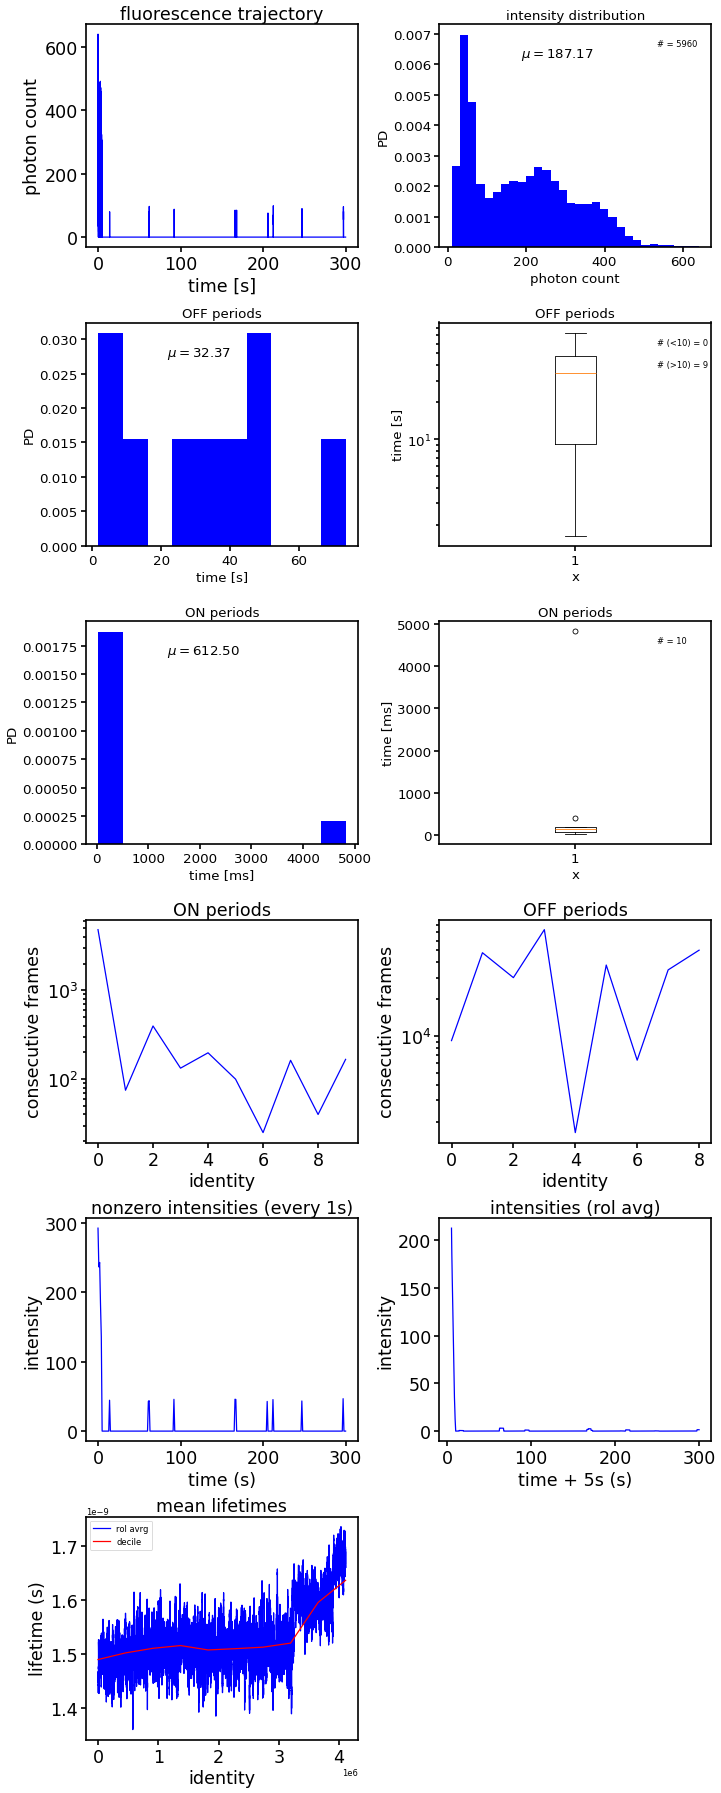

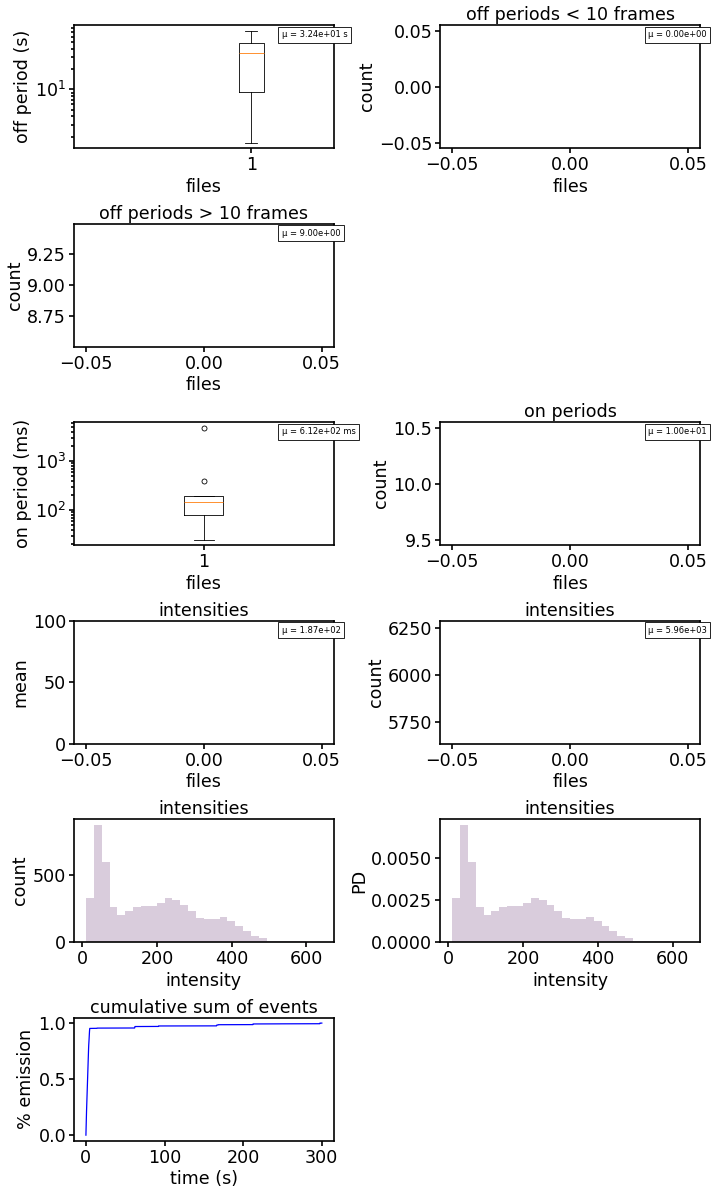

In [5]:
sda.simulate_data(number_of_simulations=number_of_simulations, memory=memory, 
                  threshold=threshold, transition_set=transition_set,
                  long_sim=True)